# Finlora Fraud Risk-Scoring: Model Selection

Fifth deliverable in the pipeline: train several candidate models on the
engineered **training set** (`Data/splits/train_features.csv`, from
`notebooks/preprocessing_feature_engineering.ipynb`) and compare them on the
held-out **validation set** (`Data/splits/val.csv`) to pick a winner. The
**test set is never touched here** -- it stays reserved for a final, one-time
evaluation in a later notebook, so model-selection decisions can't leak into
that final number.

**Contents**
1. Load training data, fitted preprocessor, and feature config
2. Prepare the validation set (same feature engineering, transform-only)
3. Candidate models
4. Train each candidate on the training set
5. Evaluate every candidate on the validation set
6. Choose an operating threshold and inspect confusion matrices
7. Select and save the winning model


In [1]:
import json
from pathlib import Path

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    average_precision_score, classification_report, confusion_matrix,
    precision_recall_curve, roc_auc_score, roc_curve, ConfusionMatrixDisplay,
)

sns.set_theme(style="whitegrid", rc={
    "font.size": 12, "axes.titlesize": 16, "axes.labelsize": 13,
    "xtick.labelsize": 12, "ytick.labelsize": 12, "legend.fontsize": 12,
    "axes.titleweight": "bold",
})
pd.set_option("display.max_columns", None)

RANDOM_STATE = 42
TARGET_RECALL = 0.70

MODEL_COLORS = {
    "Logistic Regression": "#2A6FDB",
    "Random Forest": "#00A896",
    "Gradient Boosting": "#F4A300",
}

## 1. Load training data, fitted preprocessor, and feature config

In [2]:
ARTIFACTS_DIR = Path("../artifacts")
DATA_DIR = Path("../Data/splits")

train_fe = pd.read_csv(DATA_DIR / "train_features.csv")
preprocessor = joblib.load(ARTIFACTS_DIR / "preprocessor.joblib")
with open(ARTIFACTS_DIR / "feature_config.json") as f:
    feature_config = json.load(f)

categorical_features = feature_config["categorical_features"]
numeric_features = feature_config["numeric_features"]
feature_columns = feature_config["feature_columns"]
target_column = feature_config["target_column"]

X_train = train_fe[feature_columns]
y_train = train_fe[target_column]

print("train shape:", X_train.shape)
print(f"train fraud rate: {y_train.mean():.4%}")

train shape: (88200, 21)
train fraud rate: 2.6599%


## 2. Prepare the validation set

The **same** feature-engineering function used on training data in the
previous notebook, applied here to `val.csv` -- and the **same fitted**
preprocessor, called with `.transform()` only (never `.fit()` again), so
nothing about the validation set's distribution influences the encoder's
categories or the scaler's mean/variance.

In [3]:
def engineer_features(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()

    hour_bins = [-1, 5, 11, 17, 23]
    hour_labels = ["Night", "Morning", "Afternoon", "Evening"]
    df["hour_bucket"] = pd.cut(df["hour_of_day"], bins=hour_bins, labels=hour_labels).astype(str)

    df["is_weekend"] = df["day_of_week"].isin(["Saturday", "Sunday"]).astype(int)

    df["amount_log"] = np.log1p(df["amount"].clip(lower=0))

    df["velocity_flag"] = (df["transaction_velocity_1h"] >= 1).astype(int)

    return df


val = pd.read_csv(DATA_DIR / "val.csv")
val_fe = engineer_features(val)

X_val = val_fe[feature_columns]
y_val = val_fe[target_column]

print("val shape:", X_val.shape)
print(f"val fraud rate: {y_val.mean():.4%}")

val shape: (18900, 21)
val fraud rate: 2.6614%


In [4]:
X_train_processed = preprocessor.transform(X_train)
X_val_processed = preprocessor.transform(X_val)

print("processed train matrix:", X_train_processed.shape)
print("processed val matrix:  ", X_val_processed.shape)

processed train matrix: (88200, 60)
processed val matrix:   (18900, 60)


## 3. Candidate models

Three candidates spanning linear and tree-based approaches, all trained with
`class_weight="balanced"` (or the boosting equivalent) given the ~2.66% fraud
rate:

- **Logistic Regression** -- fast, interpretable baseline.
- **Random Forest** -- non-linear, handles feature interactions, the stronger performer in the original single-split notebook.
- **Gradient Boosting** -- a second non-linear candidate, often stronger than a Random Forest on tabular data at the cost of longer training time.

In [5]:
candidates = {
    "Logistic Regression": LogisticRegression(
        class_weight="balanced", max_iter=1000, random_state=RANDOM_STATE
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=300, max_depth=10, class_weight="balanced",
        random_state=RANDOM_STATE, n_jobs=-1,
    ),
    "Gradient Boosting": GradientBoostingClassifier(
        n_estimators=200, max_depth=3, learning_rate=0.1, random_state=RANDOM_STATE,
    ),
}

## 4. Train each candidate on the training set

Gradient Boosting has no built-in class weighting, so its training rows are
weighted manually (inverse class frequency) to the same effect as
`class_weight="balanced"` on the other two.

In [6]:
fitted_models = {}

class_counts = y_train.value_counts()
sample_weight = y_train.map(lambda v: len(y_train) / (2 * class_counts[v])).values

for name, model in candidates.items():
    print(f"Training {name}...")
    if name == "Gradient Boosting":
        model.fit(X_train_processed, y_train, sample_weight=sample_weight)
    else:
        model.fit(X_train_processed, y_train)
    fitted_models[name] = model

print("\nDone.")

Training Logistic Regression...


Training Random Forest...


Training Gradient Boosting...



Done.


## 5. Evaluate every candidate on the validation set

With a ~2.66% positive rate, accuracy is not a meaningful metric. ROC-AUC and
**PR-AUC** (the more relevant of the two at this imbalance) are computed on
the validation set for every candidate.

In [7]:
val_proba = {name: model.predict_proba(X_val_processed)[:, 1] for name, model in fitted_models.items()}

results = pd.DataFrame({
    "model": list(fitted_models.keys()),
    "roc_auc": [roc_auc_score(y_val, val_proba[name]) for name in fitted_models],
    "pr_auc": [average_precision_score(y_val, val_proba[name]) for name in fitted_models],
}).sort_values("pr_auc", ascending=False).reset_index(drop=True)
results

,model,roc_auc,pr_auc
0,Gradient Boosting,0.945115,0.688697
1,Random Forest,0.943829,0.651772
2,Logistic Regression,0.938068,0.619924


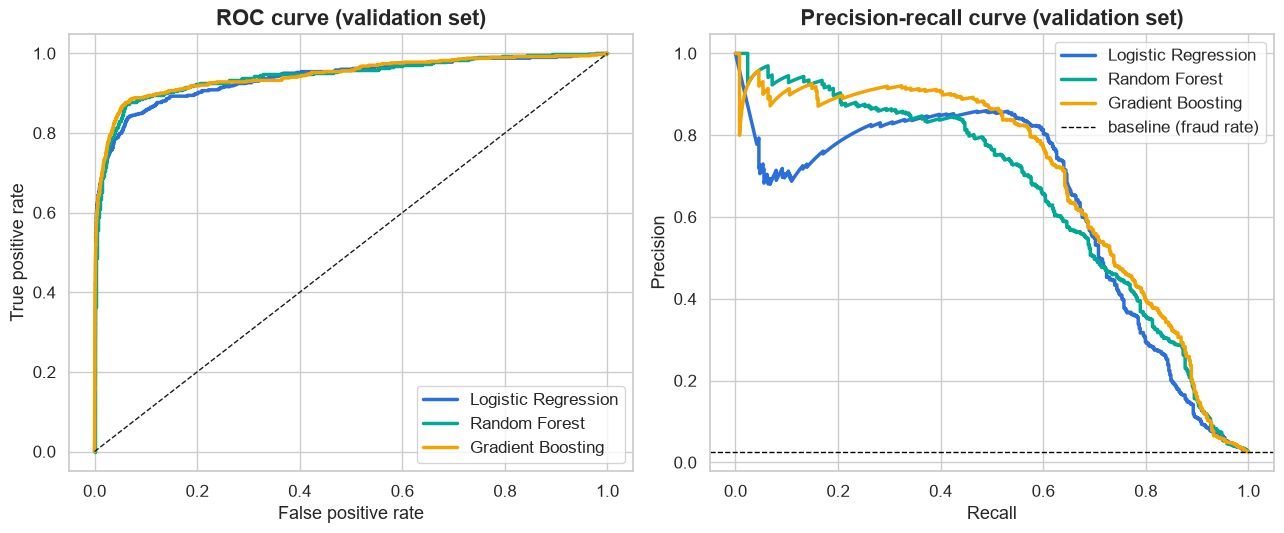

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))

for name, proba in val_proba.items():
    color = MODEL_COLORS[name]
    fpr, tpr, _ = roc_curve(y_val, proba)
    axes[0].plot(fpr, tpr, label=name, color=color, linewidth=2.5)

    precision, recall, _ = precision_recall_curve(y_val, proba)
    axes[1].plot(recall, precision, label=name, color=color, linewidth=2.5)

axes[0].plot([0, 1], [0, 1], "k--", linewidth=1)
axes[0].set_xlabel("False positive rate")
axes[0].set_ylabel("True positive rate")
axes[0].set_title("ROC curve (validation set)")
axes[0].legend()

axes[1].axhline(y_val.mean(), color="black", linestyle="--", linewidth=1, label="baseline (fraud rate)")
axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")
axes[1].set_title("Precision-recall curve (validation set)")
axes[1].legend()

plt.tight_layout()
plt.show()

## 6. Choose an operating threshold and inspect confusion matrices

As in the earlier single-split notebook, the threshold on each model's PR
curve that first reaches **70% recall** is used as an example operating
point.

In [9]:
def threshold_for_recall(y_true, proba, target_recall=TARGET_RECALL):
    precision, recall, thresholds = precision_recall_curve(y_true, proba)
    idx_candidates = np.where(recall[:-1] >= target_recall)[0]
    if len(idx_candidates) == 0:
        return thresholds[-1]
    idx = idx_candidates[-1]
    return thresholds[idx]


thresholds = {}
for name, proba in val_proba.items():
    thresh = threshold_for_recall(y_val, proba)
    thresholds[name] = thresh
    preds = (proba >= thresh).astype(int)
    print(f"=== {name} (threshold={thresh:.4f}) ===")
    print(classification_report(y_val, preds, target_names=["Legitimate", "Fraud"]))

=== Logistic Regression (threshold=0.6516) ===
              precision    recall  f1-score   support

  Legitimate       0.99      0.98      0.99     18397
       Fraud       0.55      0.70      0.62       503

    accuracy                           0.98     18900
   macro avg       0.77      0.84      0.80     18900
weighted avg       0.98      0.98      0.98     18900

=== Random Forest (threshold=0.7138) ===
              precision    recall  f1-score   support

  Legitimate       0.99      0.98      0.99     18397
       Fraud       0.50      0.70      0.58       503

    accuracy                           0.97     18900
   macro avg       0.74      0.84      0.78     18900
weighted avg       0.98      0.97      0.98     18900

=== Gradient Boosting (threshold=0.8587) ===
              precision    recall  f1-score   support

  Legitimate       0.99      0.98      0.99     18397
       Fraud       0.56      0.70      0.62       503

    accuracy                           0.98     1

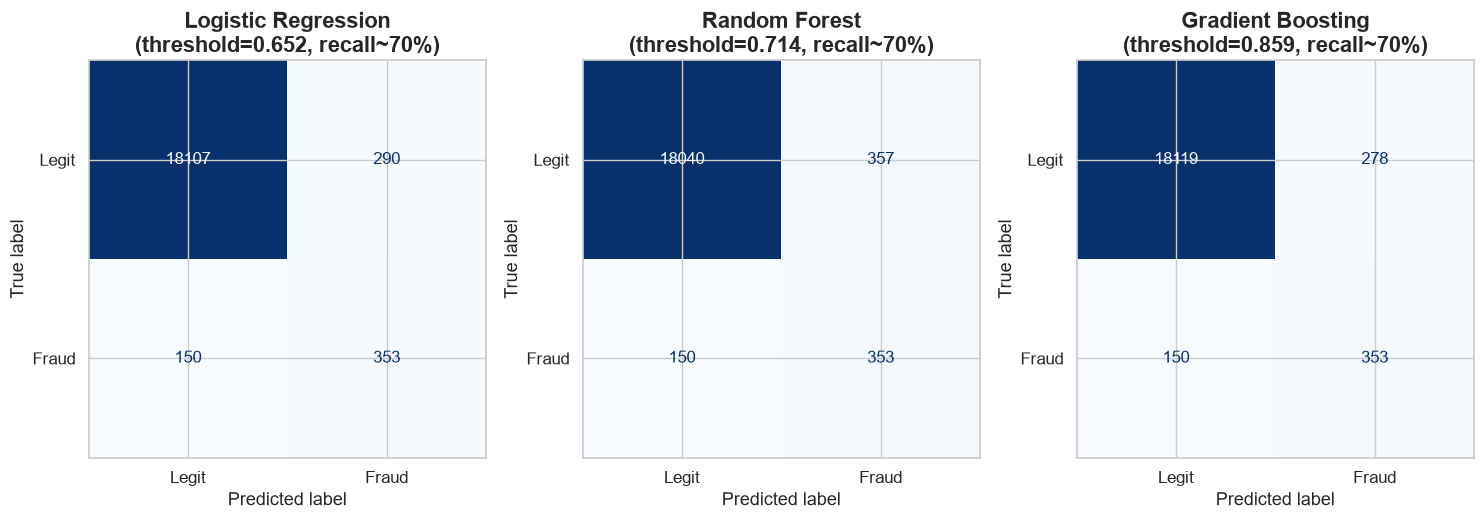

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, (name, proba) in zip(axes, val_proba.items()):
    preds = (proba >= thresholds[name]).astype(int)
    cm = confusion_matrix(y_val, preds)
    ConfusionMatrixDisplay(cm, display_labels=["Legit", "Fraud"]).plot(ax=ax, colorbar=False, cmap="Blues")
    ax.set_title(f"{name}\n(threshold={thresholds[name]:.3f}, recall~{TARGET_RECALL:.0%})")

plt.tight_layout()
plt.show()

## 7. Select and save the winning model

The candidate with the highest **PR-AUC on validation** is served -- PR-AUC,
not ROC-AUC, is the relevant metric given the ~2.66% positive rate: ROC-AUC is
dominated by the (huge) legitimate class and can look similar across models
that differ a lot in how well they rank the rare fraud cases.

In [11]:
best_name = results.iloc[0]["model"]
best_model = fitted_models[best_name]
best_threshold = thresholds[best_name]

print(f"Selected model: {best_name}")
print(f"  Validation PR-AUC:  {results.iloc[0]['pr_auc']:.4f}")
print(f"  Validation ROC-AUC: {results.iloc[0]['roc_auc']:.4f}")
print(f"  Operating threshold (~{TARGET_RECALL:.0%} recall): {best_threshold:.4f}")

Selected model: Gradient Boosting
  Validation PR-AUC:  0.6887
  Validation ROC-AUC: 0.9451
  Operating threshold (~70% recall): 0.8587


In [12]:
OUT_ARTIFACTS_DIR = Path("../artifacts")
OUT_ARTIFACTS_DIR.mkdir(exist_ok=True)

joblib.dump(best_model, OUT_ARTIFACTS_DIR / "selected_model.joblib")
for name, model in fitted_models.items():
    slug = name.lower().replace(" ", "_")
    joblib.dump(model, OUT_ARTIFACTS_DIR / f"model_{slug}.joblib")

selection_summary = {
    "selected_model": best_name,
    "selection_metric": "pr_auc",
    "operating_threshold": float(best_threshold),
    "target_recall": TARGET_RECALL,
    "random_state": RANDOM_STATE,
    "validation_results": results.to_dict(orient="records"),
}
with open(OUT_ARTIFACTS_DIR / "model_selection.json", "w") as f:
    json.dump(selection_summary, f, indent=2)

print("Saved:")
print(" ", OUT_ARTIFACTS_DIR / "selected_model.joblib", f"({best_name})")
for name in fitted_models:
    slug = name.lower().replace(" ", "_")
    print(" ", OUT_ARTIFACTS_DIR / f"model_{slug}.joblib")
print(" ", OUT_ARTIFACTS_DIR / "model_selection.json")

Saved:
  ..\artifacts\selected_model.joblib (Gradient Boosting)
  ..\artifacts\model_logistic_regression.joblib
  ..\artifacts\model_random_forest.joblib
  ..\artifacts\model_gradient_boosting.joblib
  ..\artifacts\model_selection.json


**Note:** the test set (`Data/splits/test.csv`) has not been read anywhere in
this notebook. It stays reserved for a single, final evaluation of
`selected_model.joblib` in a later notebook.